# 01 - Data Understanding



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# Robust path handling
BASE = Path(r'c:\Users\shett\Downloads\Projects\Corp_Bond_Project')
RAW = BASE / 'Data' / 'Raw'

---
## Section 1: Load & Inspect
Each raw CSV is loaded and inspected for shape, date range, and missing values.

In [2]:
def load_and_describe(name):
    """Load CSV, parse dates, show summary."""
    df = pd.read_csv(RAW / f'{name}.csv', index_col='date', parse_dates=True)
    print(f"\n{'='*60}\n{name.upper()}\n{'='*60}")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    return df

yields = load_and_describe('bond_yields')
macro = load_and_describe('macro_factors')
spreads = load_and_describe('credit_spreads')
market = load_and_describe('market_indicators')


BOND_YIELDS
Shape: (769, 6)
Date range: 1962-01-31 to 2026-01-31

Missing values:
y1       0
y2     173
y5       0
y10      0
y20     81
y30    181
dtype: int64

MACRO_FACTORS
Shape: (1284, 5)
Date range: 1919-01-31 to 2025-12-31

Missing values:
cpi         338
indpro        1
unrate      349
fedfunds    426
m2          481
dtype: int64

CREDIT_SPREADS
Shape: (1285, 3)
Date range: 1919-01-31 to 2026-01-31

Missing values:
baa         1
aaa         1
baa10y    804
dtype: int64

MARKET_INDICATORS
Shape: (433, 2)
Date range: 1990-01-31 to 2026-01-31

Missing values:
vix        0
sp500    312
dtype: int64


---
## Section 2: Economic Meaning (MANDATORY)

| Variable | Meaning | Importance |
|----------|---------|----------------|
| **y1-y30** | Treasury yields at 1Y-30Y maturities | Term structure of risk-free rates |
| **cpi** | Consumer Price Index | Inflation erodes bond returns |
| **indpro** | Industrial Production Index | Real economic activity |
| **unrate** | Unemployment Rate | Labor market slack â†’ Fed reaction |
| **fedfunds** | Federal Funds Rate | Short-term policy rate anchor |
| **m2** | M2 Money Supply | Liquidity conditions / QE |
| **baa** | Moody's Baa Corporate Yield | Investment-grade credit benchmark |
| **aaa** | Moody's Aaa Corporate Yield | Highest-quality credit |
| **baa10y** | Baa minus 10Y Treasury | Credit risk premium |
| **vix** | CBOE Volatility Index | Fear/uncertainty gauge |
| **sp500** | S&P 500 Index | Equity market state |

---
## Section 3: Raw Visualizations
### 3.1 Yield Curve Over Time

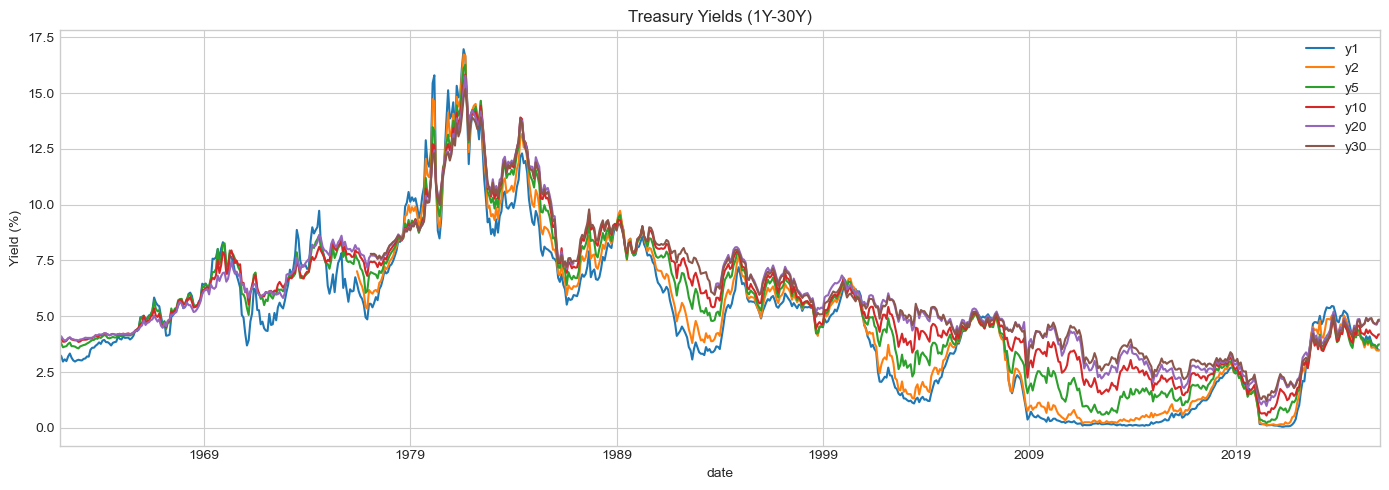

In [3]:
yields.plot(title='Treasury Yields (1Y-30Y)', ylabel='Yield (%)')
plt.tight_layout(); plt.show()

### 3.2 Macro Factors

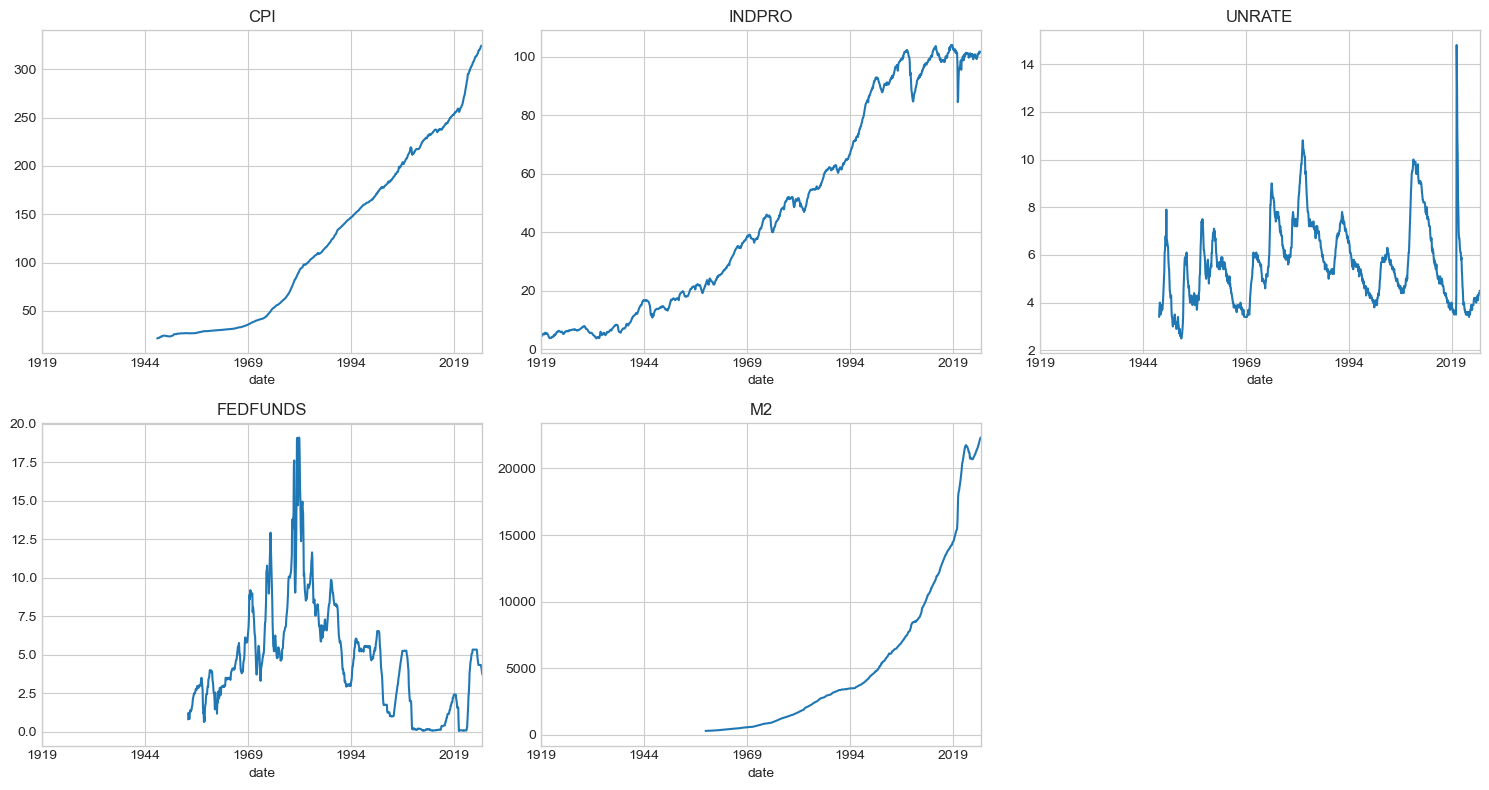

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, macro.columns):
    macro[col].plot(ax=ax, title=col.upper())
axes.flat[-1].set_visible(False)
plt.tight_layout(); plt.show()

### 3.3 Credit Spreads

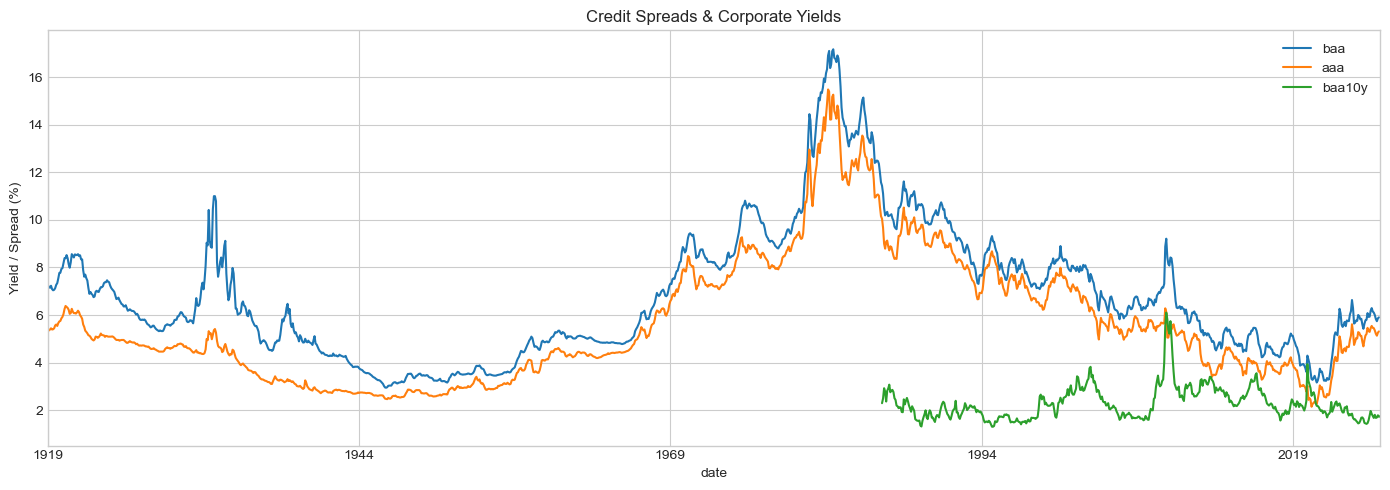

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
spreads.plot(ax=ax, title='Credit Spreads & Corporate Yields')
ax.set_ylabel('Yield / Spread (%)')
plt.tight_layout(); plt.show()

### 3.4 Market Indicators

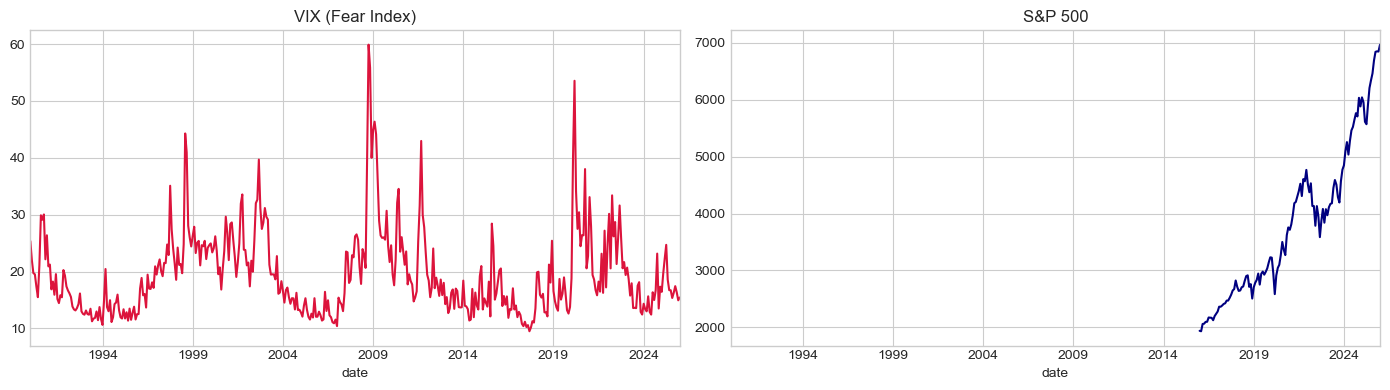

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
market['vix'].plot(ax=axes[0], title='VIX (Fear Index)', color='crimson')
market['sp500'].plot(ax=axes[1], title='S&P 500', color='navy')
plt.tight_layout(); plt.show()

### 3.5 Credit Spread vs 10Y Yield

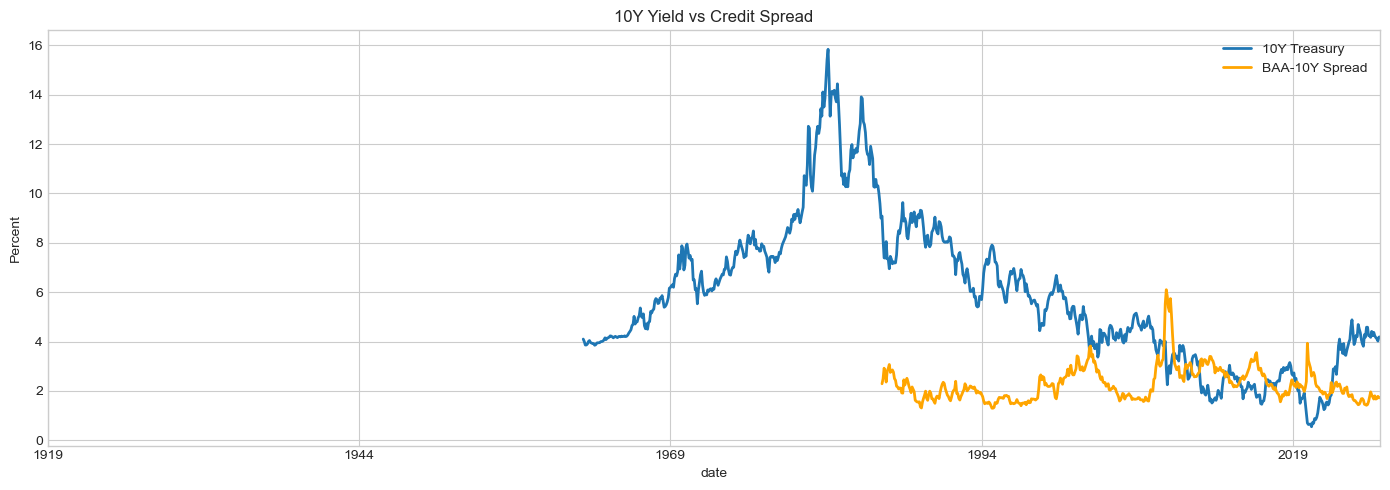

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
yields['y10'].plot(ax=ax, label='10Y Treasury', linewidth=2)
spreads['baa10y'].plot(ax=ax, label='BAA-10Y Spread', linewidth=2, color='orange')
ax.set_ylabel('Percent'); ax.legend(); ax.set_title('10Y Yield vs Credit Spread')
plt.tight_layout(); plt.show()

### 3.6 VIX vs Yields

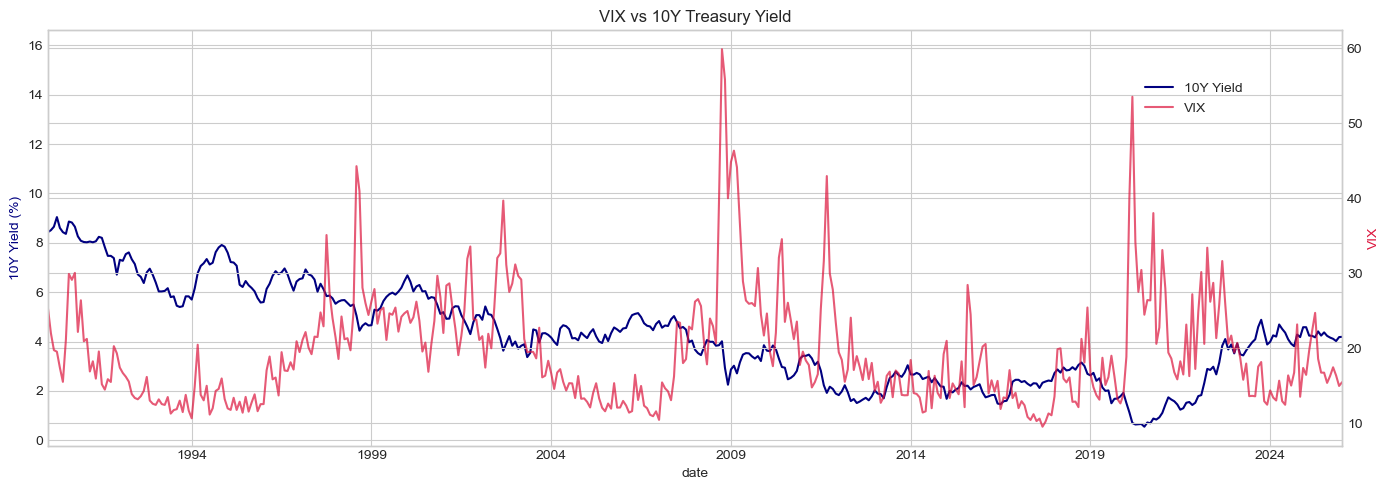

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
yields['y10'].plot(ax=ax1, color='navy', label='10Y Yield')
market['vix'].plot(ax=ax2, color='crimson', alpha=0.7, label='VIX')
ax1.set_ylabel('10Y Yield (%)', color='navy')
ax2.set_ylabel('VIX', color='crimson')
ax1.set_title('VIX vs 10Y Treasury Yield')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))
plt.tight_layout(); plt.show()

---
## Section 4: Observations

### Regime Periods Identified
1. **Pre-COVID (2016-2019)**: Gradual Fed tightening cycle, low volatility
2. **COVID Crash (Mar 2020)**: VIX spike to 53, yields collapsed to near-zero
3. **Zero Lower Bound (2020-2021)**: Fed Funds at 0%, massive QE, M2 surge
4. **Inflation Surge (2022-2023)**: Aggressive rate hikes, yield curve inversion

### Visible Structural Breaks
- **March 2020**: COVID shock as” all series show discontinuity
- **Q1 2022**: Start of rate hike cycle as” yields rise sharply
- **2023**: Yield curve inversion (2Y > 10Y)

### Data Quality Concerns
- VIX has extreme spikes (>50) that may need careful handling
- M2 growth accelerated post-2020 due to definition change + QE
- Short history (2016+) limits pre-GFC regime coverage

---
